In [4]:
print("Hello World")

Hello World


In [119]:
import json 
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split  # used to break the training data 
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.utils import to_categorical 



In [2]:
df_stair = pd.read_json("data/processed_stair_data/processed_john_5_stair.json", lines=True) 
df_treadmill = pd.read_json("data/treadmill_imu_data/imu_data_treadmill_5min_1.9mph.json", lines=True)  


### Exploratory Data Analysis

In [45]:
expected_sensors = {'Left Knee', 'Left Ankle', 'Left Hip', 'Right Knee', 'Right Ankle', 'Right Hip'}

check if any timestamp has a missing sensor value

In [65]:
# staircase 

with open("data/processed_stair_data/processed_john_5_stair.json", "r") as stair: 
    entiresStairs = [json.loads(line) for line in stair] 
    
for entry in entiresStairs: 
    sensor_locations = {s["location"] for s in entry["sensors"]} 
    if sensor_locations != expected_sensors: 
        print(f"Missing sensor at {entry}") 
        
# treadmill 

with open("data/treadmill_imu_data/imu_data_treadmill_5min_1.9mph.json", "r") as treadmill: 
    entriesTreadMill = [json.loads(line) for line in treadmill]  

for entry in entriesTreadMill: 
    sensor_locations = {s["location"] for s in entry["sensors"]} 
    if sensor_locations != expected_sensors: 
        print(f"Missing sensor at {entry}") 
        
#runs with no errors, consistent sensor readings per timestamp 

check for uniform time intervals

In [66]:
timestampsStair = pd.to_datetime([entry['timestamp'] for entry in entiresStairs]) 
timestampsTreadMill= pd.to_datetime([entry['timestamp'] for entry in entriesTreadMill]) 

time_diffsStair = timestampsStair.diff().dropna()
time_diffsTreadMill = timestampsTreadMill.dropna()

print(time_diffsStair.value_counts())
print(time_diffsTreadMill.value_counts())

0 days 00:00:00.101000      1817
0 days 00:00:00.100000       505
0 days 00:00:00.102000        67
-1 days +23:59:59.345000       8
0 days 00:00:00.002000         8
                            ... 
-1 days +23:59:59.336000       1
-1 days +23:59:59.272000       1
0 days 00:00:00.227000         1
-1 days +23:59:59.975000       1
-1 days +23:59:59.965000       1
Name: count, Length: 271, dtype: int64
2025-03-06 01:21:49.560    2
2025-03-06 01:23:44.670    2
2025-03-06 01:19:11.599    1
2025-03-06 01:22:38.890    1
2025-03-06 01:22:37.282    1
                          ..
2025-03-06 01:20:54.814    1
2025-03-06 01:20:54.915    1
2025-03-06 01:20:55.170    1
2025-03-06 01:20:55.118    1
2025-03-06 01:24:39.121    1
Name: count, Length: 3067, dtype: int64


flatten JSON into DF friendly for staircase

In [ ]:
flat_stair = [] 

for entry in entiresStairs: 
    row = {'timestamp':entry['timestamp']}
    for sensor in entry['sensors']: 
        loc = sensor['location'].replace(" ", "_") 
        for axis in ['heading','pitch','roll']:
            row[f"{loc}_{axis}"] = sensor['euler'][axis] 
            
    flat_stair.append(row) 
    
df_stair = pd.DataFrame(flat_stair) 
df_stair['timestamp'] = pd.to_datetime(df_stair['timestamp']) 
df_stair.set_index('timestamp', inplace=True) 

In [80]:
print(df_stair.isnull().sum()) 
print(df_stair.info()) 


Left_Knee_heading      0
Left_Knee_pitch        0
Left_Knee_roll         0
Left_Ankle_heading     0
Left_Ankle_pitch       0
Left_Ankle_roll        0
Left_Hip_heading       0
Left_Hip_pitch         0
Left_Hip_roll          0
Right_Ankle_heading    0
Right_Ankle_pitch      0
Right_Ankle_roll       0
Right_Knee_heading     0
Right_Knee_pitch       0
Right_Knee_roll        0
Right_Hip_heading      0
Right_Hip_pitch        0
Right_Hip_roll         0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2978 entries, 2025-03-29 17:16:16.424000 to 2025-03-29 17:21:16.554000
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Left_Knee_heading    2978 non-null   float64
 1   Left_Knee_pitch      2978 non-null   float64
 2   Left_Knee_roll       2978 non-null   float64
 3   Left_Ankle_heading   2978 non-null   float64
 4   Left_Ankle_pitch     2978 non-null   float64
 5   Left_Ankle_roll      2978

In [76]:
df_stair.head() 

,Left_Knee_heading,Left_Knee_pitch,Left_Knee_roll,Left_Ankle_heading,Left_Ankle_pitch,Left_Ankle_roll,Left_Hip_heading,Left_Hip_pitch,Left_Hip_roll,Right_Ankle_heading,Right_Ankle_pitch,Right_Ankle_roll,Right_Knee_heading,Right_Knee_pitch,Right_Knee_roll,Right_Hip_heading,Right_Hip_pitch,Right_Hip_roll
timestamp,,,,,,,,,,,,,,,,,,
2025-03-29 17:16:16.424,-6.06125,-1.76125,5.293125,-1.773125,-23.03875,1.67375,-7.3125,24.524375,-19.45375,13.8225,61.935625,11.710625,11.88125,5.81625,9.4025,-10.88375,-12.46875,7.883125
2025-03-29 17:16:16.525,-5.87375,0.11375,7.105625,3.664375,-20.53875,5.04875,-5.3125,25.461875,-18.01625,15.0725,61.998125,11.773125,12.19375,4.62875,9.2150,-11.75875,-17.28125,8.008125
2025-03-29 17:16:16.627,-1.49875,-1.26125,5.355625,7.289375,-17.28875,7.86125,-2.2500,25.274375,-16.76625,14.9475,60.873125,10.648125,11.31875,2.44125,8.0900,-11.57125,-20.09375,8.195625
2025-03-29 17:16:16.727,1.68875,-1.63625,3.355625,10.726875,-14.22625,10.36125,2.6250,31.024375,-13.26625,14.8850,-11.564375,9.210625,10.81875,0.31625,6.8400,-10.25875,-23.09375,7.695625
2025-03-29 17:16:16.828,5.87625,1.42625,1.105625,13.226875,63.52375,11.54875,0.6250,28.961875,-11.32875,15.5725,-7.814375,8.210625,9.88125,0.69125,5.6525,-12.19625,-27.96875,7.570625


flatten JSON into DF friendly for treadmill

In [73]:
flat_treadMill = [] 

for entry in entriesTreadMill: 
    row = {'timestamp':entry['timestamp']}
    for sensor in entry['sensors']: 
        loc = sensor['location'].replace(" ", "_") 
        for axis in ['heading','pitch','roll']:
            row[f"{loc}_{axis}"] = sensor['euler'][axis] 
            
    flat_treadMill.append(row) 
    
df_treadmill = pd.DataFrame(flat_treadMill) 
df_treadmill['timestamp'] = pd.to_datetime(df_treadmill['timestamp']) 
df_treadmill.set_index('timestamp', inplace=True) 

In [79]:
print(df_treadmill.isnull().sum()) 
print(df_treadmill.info()) 


Left_Knee_heading      0
Left_Knee_pitch        0
Left_Knee_roll         0
Left_Ankle_heading     0
Left_Ankle_pitch       0
Left_Ankle_roll        0
Right_Ankle_heading    0
Right_Ankle_pitch      0
Right_Ankle_roll       0
Right_Hip_heading      0
Right_Hip_pitch        0
Right_Hip_roll         0
Right_Knee_heading     0
Right_Knee_pitch       0
Right_Knee_roll        0
Left_Hip_heading       0
Left_Hip_pitch         0
Left_Hip_roll          0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3069 entries, 2025-03-06 01:19:11.599000 to 2025-03-06 01:24:39.121000
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Left_Knee_heading    3069 non-null   float64
 1   Left_Knee_pitch      3069 non-null   float64
 2   Left_Knee_roll       3069 non-null   float64
 3   Left_Ankle_heading   3069 non-null   float64
 4   Left_Ankle_pitch     3069 non-null   float64
 5   Left_Ankle_roll      3069

In [77]:
df_treadmill.head() 

,Left_Knee_heading,Left_Knee_pitch,Left_Knee_roll,Left_Ankle_heading,Left_Ankle_pitch,Left_Ankle_roll,Right_Ankle_heading,Right_Ankle_pitch,Right_Ankle_roll,Right_Hip_heading,Right_Hip_pitch,Right_Hip_roll,Right_Knee_heading,Right_Knee_pitch,Right_Knee_roll,Left_Hip_heading,Left_Hip_pitch,Left_Hip_roll
timestamp,,,,,,,,,,,,,,,,,,
2025-03-06 01:19:11.599,367.625,128.8125,35.5000,100.5000,107.6875,37.000,53.3750,-3.6875,13.0000,103.6875,-149.1250,42.6875,165.2500,-144.4375,-50.6250,49.3750,-145.6875,64.3750
2025-03-06 01:19:11.699,358.375,125.4375,31.1250,105.3125,109.8125,41.375,72.3750,1.1250,15.3125,94.4375,-152.4375,44.5000,147.5625,-132.1250,-38.9375,51.0625,-152.7500,66.1250
2025-03-06 01:19:11.800,5.750,122.9375,24.8125,112.3750,114.1250,48.375,74.3125,5.4375,14.0000,83.3750,-156.0625,47.7500,148.3750,-133.5000,-36.1875,53.1250,-159.0625,67.1250
2025-03-06 01:19:11.900,16.875,122.0625,14.5000,119.1250,124.3750,58.875,62.9375,6.6250,12.6875,83.6250,-155.5000,50.6875,165.8750,-143.0000,-41.5625,53.5625,-157.3750,67.5000
2025-03-06 01:19:12.100,31.125,122.0000,5.4375,136.5000,156.4375,68.125,56.8750,9.0000,11.0000,79.5625,-156.2500,56.1875,182.2500,-150.0625,-47.0625,38.5000,-130.8750,63.5625


Individual data frames are complete i.e no missing values

combine and create new column that labels each time stamp as either a 0 or 1 

0: treadmill (i.e walking)

1: staircase (i.e climbing) 

## CNN 

In [101]:
df_treadmill['label'] = 0 
df_stair['label'] = 1 


In [111]:
from sklearn.preprocessing import StandardScaler

featuresTreadmill = df_treadmill.drop(columns=['label'])
featuresStair = df_stair.drop(columns=['label']) 
scaler = StandardScaler() 

scaled_featuresTreadmill = scaler.fit_transform(featuresTreadmill) 
scaled_featuresStair = scaler.fit_transform(featuresStair) 

df_treadmill[featuresTreadmill.columns] = scaled_featuresTreadmill 
df_stair[featuresStair.columns] = scaled_featuresStair 



In [113]:

# use sliding window to segment continuous activity into equal-length sequences

def create_sequence(df, window_size = 25, stride=5):
    X, y = [], [] 
    data = df.drop(columns=['label']).values
    labels = df['label'].values
    for i in range(0,len(df) - window_size, stride): 
        seq = data[i:i+window_size]
        label = labels[i+window_size - 1 ] 
        X.append(seq)
        y.append(label)
    
    return X, y 


X_walk, y_walk = create_sequence(df_treadmill, window_size=25, stride=5) 
X_stair, y_stair = create_sequence(df_stair, window_size=25, stride=5) 

X = np.array(X_walk + X_stair) 
y = np.array(y_walk + y_stair) 

In [118]:
print(X.shape)
y.shape

(1200, 25, 18)


(1200,)

### 1D CNN Model

In [123]:
y_cat = to_categorical(y) 

#train-test-split
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, train_size=0.8, random_state=42, stratify=y)

# 1D CNN model 

model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(25,18)), MaxPooling1D(pool_size=2),Dropout(0.3), 
    
    Conv1D(filters=128, kernel_size=3, activation='relu'), MaxPooling1D(pool_size=2), Dropout(0.3),
    
    Flatten(), Dense(64, activation='relu'),Dropout(0.3), Dense(2, activation='softmax') 
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

hist = model.fit(X_train, y_train, epochs=20, batch_size = 32, validation_data=(X_test, y_test))

Epoch 1/20


/Users/qusayqadir/Documents/github/ExoSkeleton Gait Classifer /.venv/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6872 - loss: 0.6180 - val_accuracy: 1.0000 - val_loss: 0.0337
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9941 - loss: 0.0506 - val_accuracy: 1.0000 - val_loss: 6.6663e-04
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 1.8220e-04
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 9.3235e-04 - val_accuracy: 1.0000 - val_loss: 1.0043e-04
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 9.6703e-04 - val_accuracy: 1.0000 - val_loss: 5.6222e-05
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 5.0916e-04 - val_accuracy: 1.0000 - val_loss: 3.5478e-05
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 5.1362e-04 - val_accuracy: 1.0000 - val_loss: 2.2875e-05
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 2.6237e-04 -

In [135]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Loss: {loss:.10f}, Accuracy: {accuracy:.2f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 1.7181e-06 
Loss: 0.0000017707, Accuracy: 1.00


loss is nearing 0 and accuracy is 100% 

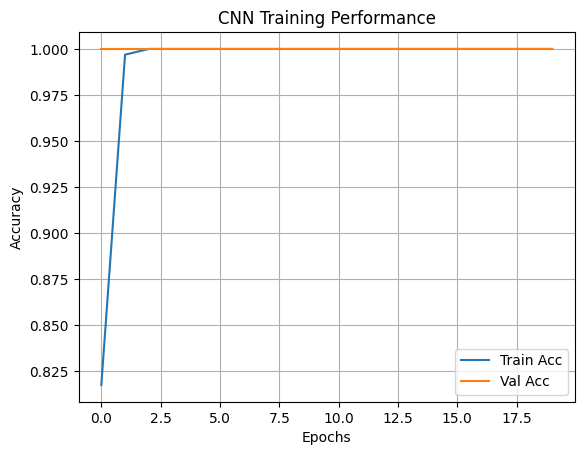

In [140]:
import matplotlib.pyplot as plt

plt.plot(hist.history['accuracy'], label='Train Acc')
plt.plot(hist.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CNN Training Performance')
plt.legend()
plt.grid(True)
plt.show()

## FeedForward Neural Network: FNN 

In [127]:
df_treadmill['label'] = 0 
df_stair['label'] = 1 
# do not need to worry about missing or incomplete data 

#combine dataframes
df = pd.concat([df_treadmill, df_stair], axis=0)

#shuffle the columns
df = df.sample(frac=1, random_state=42).reset_index(drop=True) 


print(df['label'].value_counts())
df.head(n=10) 

label
0    3069
1    2978
Name: count, dtype: int64


,Left_Knee_heading,Left_Knee_pitch,Left_Knee_roll,Left_Ankle_heading,Left_Ankle_pitch,Left_Ankle_roll,Right_Ankle_heading,Right_Ankle_pitch,Right_Ankle_roll,Right_Hip_heading,Right_Hip_pitch,Right_Hip_roll,Right_Knee_heading,Right_Knee_pitch,Right_Knee_roll,Left_Hip_heading,Left_Hip_pitch,Left_Hip_roll,label
0,0.342644,1.195885,0.282976,0.719184,0.609635,0.789210,0.322825,-0.485249,-0.430982,0.015477,-0.217667,0.465924,-0.507773,-0.224058,-0.991062,-0.203080,0.369226,0.148463,1
1,-0.594986,0.515785,0.849676,-1.013153,-0.393919,-1.395918,-0.176574,-0.206970,-1.597901,0.906516,-0.296808,0.816408,1.863429,-0.060511,0.677008,-0.372630,0.356488,-0.167473,0
2,-0.878331,-0.081995,0.470372,0.058396,0.046909,-0.017122,-0.883532,-0.647893,0.048743,0.280704,0.484231,-0.325619,-0.504380,-0.284309,0.021560,1.658435,3.084669,1.545197,1
3,1.350145,-1.670199,-1.810845,-0.570946,-0.263343,-0.135574,-0.908130,-0.447645,0.231575,-0.603568,0.104750,0.488847,-0.154514,-0.350397,0.421475,-0.161846,0.073508,0.078563,1
4,-0.776901,0.358745,0.885323,-0.286441,0.109362,-0.551213,-1.182496,0.674725,-0.403414,0.175715,0.094901,-0.187153,-0.466009,-0.044670,-0.776367,-0.248993,-0.029437,-0.091420,0
5,1.441594,1.430842,1.264074,-0.109343,0.216933,-0.458295,-0.617393,1.524551,0.846631,-1.105014,0.035551,1.411111,0.394762,-0.998476,-1.618322,-0.069721,0.465119,-0.430201,0
6,-0.524481,-0.260353,0.194658,-0.091023,0.090152,-0.047205,0.139961,-0.669064,0.318834,0.287162,-0.115791,-1.060622,-1.108162,0.161252,0.465087,-0.168630,-0.383915,0.682939,0
7,-0.757525,0.331565,0.836308,-0.174076,0.397499,-0.427323,-1.172786,0.563185,-0.283039,0.144656,0.258113,-0.001308,-0.408084,-0.074088,-0.860849,-0.230448,-0.140926,-0.125989,0
8,-0.411995,-0.393233,-0.736624,0.263173,0.243826,0.766528,0.897315,-0.318510,0.892929,-0.262766,-0.388800,-0.236711,-1.295015,0.039056,0.798719,-0.082967,-1.038558,1.201482,0
9,-0.773133,-0.109353,0.658072,0.342561,0.750949,0.456802,0.095296,0.435711,0.869780,-0.288344,0.177990,-1.314610,-0.522065,-0.037882,-0.575901,0.035370,-0.849884,0.489349,0
